In [1]:
from keras.preprocessing.image import ImageDataGenerator
dataset_path = "/home/dipak/MalwareClassification/malimg_paper_dataset_imgs/"
augs_gen = ImageDataGenerator().flow_from_directory(directory=dataset_path, target_size=(64,64), batch_size=10000)

Found 9339 images belonging to 25 classes.


In [2]:
images, labels = next(augs_gen)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(images/255.,labels, test_size=0.2)

/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)
/home/dipak/anaconda3/lib/python3.7/importlib/_bootstrap.py:219: RuntimeWarning: numpy.ufunc size changed, may indicate binary incompatibility. Expected 192 from C header, got 216 from PyObject
  return f(*args, **kwds)


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import MaxPool2D,Dense,Conv2D
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import GlobalAveragePooling2D,Dense
base_model = VGG16(input_shape=(224,224,3),
                                              include_top=False,
                                              weights='imagenet')

base_model.trainable = False

# for layer in base_model.layers[:6]:
#     layer.trainable = False

classifier = Sequential([
                          base_model,
                        GlobalAveragePooling2D(),
                        Dense(128,activation='relu'),
                         Dense(25, activation='sigmoid')])

classifier.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
vgg16 (Functional)           (None, 7, 7, 512)         14714688  
_________________________________________________________________
global_average_pooling2d_1 ( (None, 512)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               65664     
_________________________________________________________________
dense_3 (Dense)              (None, 25)                3225      
Total params: 14,783,577
Trainable params: 68,889
Non-trainable params: 14,714,688
_________________________________________________________________


In [7]:
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint,ReduceLROnPlateau
earlystop = EarlyStopping(monitor='val_loss',
                         patience=6,
                         verbose=1,
                         min_delta=0.00001,
                         restore_best_weights=True)

checkpoint = ModelCheckpoint('MalingTL.h5',
                             monitor='val_loss',
                            save_best_only=True,
                            mode='auto',
                             verbose=1)

reduceLR = ReduceLROnPlateau(monitor='val_loss',
                                        patience=6,
                                        min_delta=0.00001,
                                        verbose=1,
                                        factor=0.01)

callback = [earlystop,checkpoint,reduceLR]

In [8]:
from tensorflow.keras.optimizers import SGD,RMSprop
classifier.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics='accuracy')

In [9]:
tl_history = classifier.fit(X_train, y_train, validation_data=(X_test, y_test),epochs=20,callbacks=callback)

Epoch 1/20
234/234 [==============================] - ETA: 0s - loss: 1.5624 - accuracy: 0.5247WARNING:tensorflow:Model was constructed with shape (None, 224, 224, 3) for input Tensor("vgg16_input_1:0", shape=(None, 224, 224, 3), dtype=float32), but it was called on an input with incompatible shape (None, 64, 64, 3).

Epoch 00001: val_loss improved from inf to 0.86290, saving model to MalingTL.h5
234/234 [==============================] - 258s 1s/step - loss: 1.5624 - accuracy: 0.5247 - val_loss: 0.8629 - val_accuracy: 0.6943
Epoch 2/20
234/234 [==============================] - ETA: 0s - loss: 0.7581 - accuracy: 0.7332
Epoch 00002: val_loss improved from 0.86290 to 0.67697, saving model to MalingTL.h5
234/234 [==============================] - 273s 1s/step - loss: 0.7581 - accuracy: 0.7332 - val_loss: 0.6770 - val_accuracy: 0.7479
Epoch 3/20
234/234 [==============================] - ETA: 0s - loss: 0.6241 - accuracy: 0.7755
Epoch 00003: val_loss improved from 0.67697 to 0.59059, savi

In [14]:
print("Evaluation on Test data")
tl_results = classifier.evaluate(X_test, y_test)
print("Test loss, Test acc:", tl_results)

Evaluation on Test data
59/59 [==============================] - 44s 739ms/step - loss: 0.3602 - accuracy: 0.8737
Test loss, Test acc: [0.36021965742111206, 0.8736616969108582]


In [27]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix
from sklearn.metrics import plot_confusion_matrix,classification_report
labels = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
               'Lolyda.AA1','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A','FinalA']
y_pred = classifier.predict_classes(X_test, verbose=0)
y_test2 = np.argmax(y_test, axis=1)
tl_reasults = confusion_matrix(y_test2, y_pred)
print(tl_reasults)

print('Classification Report')
print(classification_report(y_test2, y_pred, target_names=labels))

[[ 12   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0  22   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   1   0   0]
 [  0   0 540  39   0   0   1   0   0   0   0   0   0   0   0   0   5   0
    0   0   0   0   0   0   0]
 [  0   0  77 222   0   0   0   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0]
 [  0   0   0   0  43   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0  27]
 [  0   0   0   0   0   0  23   2   0   0   0   0   0   0   0   1   0   0
    0   0   0   2   1   1   0]
 [  0   0   0   0   0   0   5  33   0   0   0   0   0   0   0   0   0   0
    0   0   4   0   0   1   0]
 [  0   0   0   0   0   0   1   0  31   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0  33   0   0   0  

/home/dipak/anaconda3/lib/python3.7/site-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


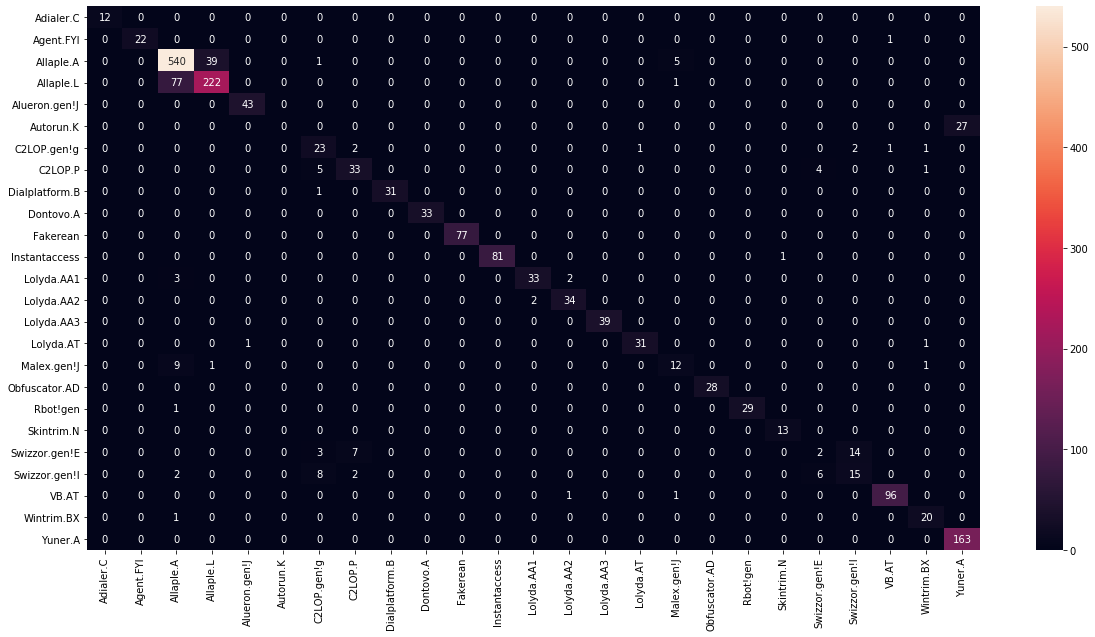

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
x_axis = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']
y_axis = ['Adialer.C','Agent.FYI','Allaple.A','Allaple.L','Alueron.gen!J','Autorun.K',
              'C2LOP.gen!g','C2LOP.P','Dialplatform.B','Dontovo.A','Fakerean','Instantaccess',
              'Lolyda.AA1','Lolyda.AA2','Lolyda.AA3','Lolyda.AT','Malex.gen!J','Obfuscator.AD','Rbot!gen',
              'Skintrim.N','Swizzor.gen!E','Swizzor.gen!I','VB.AT','Wintrim.BX','Yuner.A']


plt.figure(figsize=(20,10))
sns.heatmap(tl_reasults,annot=True,fmt='d',xticklabels=x_axis,yticklabels=y_axis)

Text(0.5, 1.0, 'Accuracy Curves')

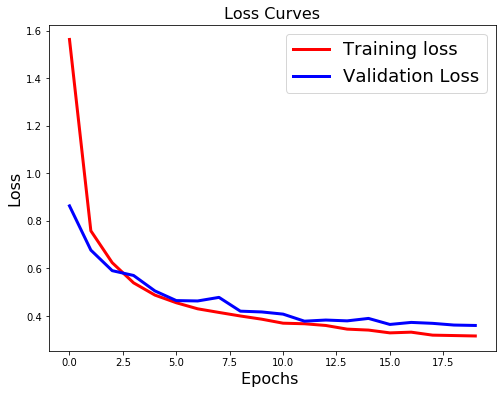

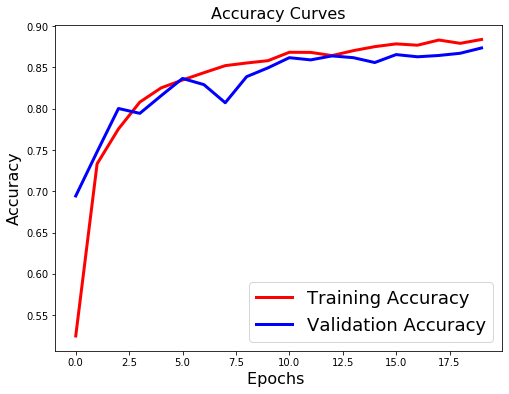

In [41]:

plt.figure(figsize=[8,6])
plt.plot(tl_history.history['loss'],'r',linewidth=3.0)
plt.plot(tl_history.history['val_loss'],'b',linewidth=3.0)
plt.legend(['Training loss', 'Validation Loss'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Loss',fontsize=16)
plt.title('Loss Curves',fontsize=16)
  
plt.figure(figsize=[8,6])
plt.plot(tl_history.history['accuracy'],'r',linewidth=3.0)
plt.plot(tl_history.history['val_accuracy'],'b',linewidth=3.0)
plt.legend(['Training Accuracy', 'Validation Accuracy'],fontsize=18)
plt.xlabel('Epochs ',fontsize=16)
plt.ylabel('Accuracy',fontsize=16)
plt.title('Accuracy Curves',fontsize=16)